<div style="height:200px;width:100%;margin: 0;">
    <img src="https://storage.googleapis.com/kaggle-competitions/kaggle/52279/logos/header.png?t=2023-05-04-23-04-20" style="width:100%;" />
</div>

In [5]:
import zipfile
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

import zipfile
import rasterio
from rasterio.windows import Window

import json
import os
import numpy as np
from tqdm import tqdm, notebook
from torch.utils.data import Dataset, DataLoader

<h3 class="list-group-item list-group-item-action active" data-toggle="list" style="color:#c3448b; background:#efe9e9; border:1px dashed #efe50b;" role="tab" aria-controls="data"><center>Metadata</center></h3>

In [6]:
BASE_DIR = "data/"

In [7]:
tile_meta = pd.read_csv(f"{BASE_DIR}/tile_meta.csv")
wsi_meta = pd.read_csv(f"{BASE_DIR}/wsi_meta.csv")

In [8]:
tile_meta.head(10)

,id,source_wsi,dataset,i,j
0,0006ff2aa7cd,2,2,16896,16420
1,000e79e206b7,6,3,10240,29184
2,00168d1b7522,2,2,14848,14884
3,00176a88fdb0,7,3,14848,25088
4,0033bbc76b6b,1,1,10240,43008
5,003504460b3a,3,2,8192,11776
6,00359ab8338b,8,3,6656,9216
7,00488ca285ee,9,3,8192,37888
8,004daf1cbe75,3,2,6144,11264
9,004fb033dd09,7,3,20480,31232


In [9]:
wsi_meta.head()

,source_wsi,age,sex,race,height,weight,bmi
0,1,58,F,W,160.0,59.0,23.0
1,2,56,F,W,175.2,139.6,45.5
2,3,73,F,W,162.3,87.5,33.2
3,4,53,M,B,166.0,73.0,26.5


<h3 class="list-group-item list-group-item-action active" data-toggle="list" style="color:#c3448b; background:#efe9e9; border:1px dashed #efe50b;" role="tab" aria-controls="plotting"><center>Plotting Data</center></h3>

In [10]:
tiff_file = f"{BASE_DIR}/train/0006ff2aa7cd.tif"
tiff_img = cv2.imread(tiff_file)

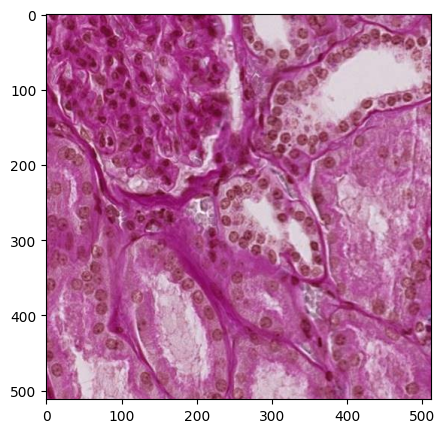

In [11]:
plt.figure(figsize=(5,5))
plt.imshow(tiff_img)
plt.show()

<h3 class="list-group-item list-group-item-action active" data-toggle="list" style="color:#c3448b; background:#efe9e9; border:1px dashed #efe50b;" role="tab" aria-controls="dataset"><center>Dataset</center></h3>

In [17]:
class HubMAP_Dataset(Dataset):
    def __init__(self, jsonPath, image_dir, augments = False, train=True):
        # read jsonl file, 
        with open(jsonPath) as json_file:
            json_list = list(json_file)
        
        # loop through the list, to create Dataframe of json Data
        dataset = []
        for json_str in tqdm(json_list, desc="Reading Json Data"):
            result = json.loads(json_str)
            
            annotations = result['annotations']
            row = {}
            for ann in annotations:
                row = {}
                row["id"] = result["id"]
                row["type"] = ann["type"]
                row["coordinates"] = ann["coordinates"]
                row["mask"] = self.coordinates_to_masks(ann["coordinates"], (512, 512))[0]
                row["rle"] = self.mask2enc(row["mask"])
                dataset.append(row)
        
        # define dataset, to make it easier to get...
        self.dataset = pd.DataFrame(dataset, columns=["id", "type", "coordinates", "mask", "rle"])                      
        self.train = train
        self.image_dir = image_dir
        
    def enc2mask(self, encs, shape):
        img = np.zeros(shape[0]*shape[1], dtype=np.uint8)
        for m,enc in enumerate(encs):
            if isinstance(enc,np.float) and np.isnan(enc): continue
            s = enc.split()
            for i in range(len(s)//2):
                start = int(s[2*i]) - 1
                length = int(s[2*i+1])
                img[start:start+length] = 1 + m
        return img.reshape(shape).T

    def mask2enc(self, mask, n=1):
        pixels = mask.T.flatten()
        encs = []
        for i in range(1,n+1):
            p = (pixels == i).astype(np.int8)
            if p.sum() == 0: encs.append(np.nan)
            else:
                p = np.concatenate([[0], p, [0]])
                runs = np.where(p[1:] != p[:-1])[0] + 1
                runs[1::2] -= runs[::2]
                encs.append(' '.join(str(x) for x in runs))
        return encs

    def coordinates_to_masks(self, coordinates, shape):
        masks = []
        for coord in coordinates:
            mask = np.zeros(shape, dtype=np.uint8)
            cv2.fillPoly(mask, [np.array(coord)], 1)
            masks.append(mask)
        return masks
        
    def __getitem__(self, idx):
        
        data = self.dataset.iloc[idx]
        
        imageLoc = os.path.join(self.image_dir,data.id+".tif")
        img = cv2.imread(imageLoc)
        
        type_struct = data.type
        coord = data.coordinates[0]
        
        # create mask array
        mask = np.zeros((512, 512), dtype=np.float32)
        points = np.array(coord)
        points = points.reshape((1, -1, 2))
        mask = cv2.fillPoly(mask, pts=points, color=(255))    
        
        return img, type_struct, mask
            
    def __len__(self):
        return len(self.dataset)

In [18]:
jsonL = f"{BASE_DIR}/polygons.jsonl"
image_dir = f"{BASE_DIR}/train"

trainDataset = HubMAP_Dataset(jsonPath=jsonL, augments=False, image_dir=image_dir, train=True)

Reading Json Data: 100%|██████████| 1633/1633 [00:15<00:00, 106.82it/s]


In [19]:
df_masks = trainDataset.dataset
df_masks.head()

,id,type,coordinates,mask,rle
0,0006ff2aa7cd,glomerulus,"[[[167, 249], [166, 249], [165, 249], [164, 24...","[[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",[2 105 513 107 1025 111 1537 113 2049 114 2561...
1,0006ff2aa7cd,blood_vessel,"[[[283, 109], [282, 109], [281, 109], [280, 10...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",[139350 10 139860 17 140370 22 140880 27 14139...
2,0006ff2aa7cd,blood_vessel,"[[[104, 292], [103, 292], [102, 292], [101, 29...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",[37108 4 37618 8 38129 11 38640 14 39152 15 39...
3,0006ff2aa7cd,blood_vessel,"[[[505, 442], [504, 442], [503, 442], [502, 44...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",[250783 11 251292 20 251801 26 252311 30 25282...
4,0006ff2aa7cd,blood_vessel,"[[[375, 477], [374, 477], [373, 477], [372, 47...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",[167352 5 167863 7 168374 10 168886 11 169398 ...


In [20]:
df_masks = df_masks[df_masks['type'] == 'blood_vessel']
df_masks.reset_index(inplace=True, drop=True)

In [22]:
df_masks['unique_id'] = df_masks['id'] + '_' + df_masks.index.astype(str)
df_masks.set_index('unique_id', inplace=True)
df_masks.head()

/tmp/ipykernel_2897/1906943928.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_masks['unique_id'] = df_masks['id'] + '_' + df_masks.index.astype(str)


,id,type,coordinates,mask,rle
unique_id,,,,,
0006ff2aa7cd_0006ff2aa7cd_0,0006ff2aa7cd,blood_vessel,"[[[283, 109], [282, 109], [281, 109], [280, 10...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",[139350 10 139860 17 140370 22 140880 27 14139...
0006ff2aa7cd_0006ff2aa7cd_1,0006ff2aa7cd,blood_vessel,"[[[104, 292], [103, 292], [102, 292], [101, 29...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",[37108 4 37618 8 38129 11 38640 14 39152 15 39...
0006ff2aa7cd_0006ff2aa7cd_2,0006ff2aa7cd,blood_vessel,"[[[505, 442], [504, 442], [503, 442], [502, 44...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",[250783 11 251292 20 251801 26 252311 30 25282...
0006ff2aa7cd_0006ff2aa7cd_3,0006ff2aa7cd,blood_vessel,"[[[375, 477], [374, 477], [373, 477], [372, 47...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",[167352 5 167863 7 168374 10 168886 11 169398 ...
0006ff2aa7cd_0006ff2aa7cd_4,0006ff2aa7cd,blood_vessel,"[[[368, 410], [367, 410], [366, 410], [365, 41...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",[171880 10 172389 18 172899 24 173410 28 17392...


In [23]:
df_masks.to_csv('labels.csv', index=False)

<h3 class="list-group-item list-group-item-action active" data-toggle="list" style="color:#c3448b; background:#efe9e9; border:1px dashed #efe50b;" role="tab" aria-controls="segment"><center>Segmentation</center></h3>

## Configuration

In [28]:
config = {
    'resize': (768,768),
    'resolution': (512,512),
    'DATA': f'{BASE_DIR}/train',
    'Window' : (250,1024),
    'bs': 64,
    'nfolds': 4,
    'fold': 0,
    'NUM_WORKERS': 4,
    'OUT_TRAIN' : 'train.zip',
    'OUT_MASKS' : 'masks.zip'
}

## Additionals

In [29]:
# functions to convert encoding to mask and mask to encoding
def enc2mask(encs, shape):
    '''
    Args:
    encs: list of rle masks
    shape: mask shape
    '''
    img = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for m,enc in enumerate(encs):
        if isinstance(enc,np.float32) and np.isnan(enc): continue
        s = enc.split()
        for i in range(len(s)//2):
            start = int(s[2*i]) - 1
            length = int(s[2*i+1])
            img[start:start+length] = 1 + m
    return img.reshape(shape).T

def mask2enc(mask, n=1):
    pixels = mask.T.flatten()
    encs = []
    for i in range(1,n+1):
        p = (pixels == i).astype(np.int8)
        if p.sum() == 0: encs.append(np.nan)
        else:
            p = np.concatenate([[0], p, [0]])
            runs = np.where(p[1:] != p[:-1])[0] + 1
            runs[1::2] -= runs[::2]
            encs.append(' '.join(str(x) for x in runs))
    return encs

## Sliding Windows Dataset

In [30]:
class HPADataset(Dataset):
    def __init__(self, idx, resize=config['resize'], slide=config['Window'], encs=None):
        self.data = rasterio.open(os.path.join(config['DATA'],str(idx)+'.tif'), num_threads='all_cpus')
        # some images have issues with their format 
        # and must be saved correctly before reading with rasterio
        if self.data.count != 3:
            subdatasets = self.data.subdatasets
            self.layers = []
            if len(subdatasets) > 0:
                for i, subdataset in enumerate(subdatasets, 0):
                    self.layers.append(rasterio.open(subdataset))
                    
        self.shape = self.data.shape
        self.slide = slide
        self.resize = resize
        self.idx = idx
        self.mask = enc2mask(encs,(self.shape[1],self.shape[0])) if encs is not None else None
        
    def __len__(self):
        return 1
    
    def __getitem__(self, idx):
        # read img (RGB), mask (grayscale) from window slide
        # img, mask: uint8
        img = self.data.read([1,2,3],window=Window.from_slices(self.slide,self.slide)) 
        mask = self.mask[self.slide[0]:self.slide[1], self.slide[0]:self.slide[1]] 
        
        # resize
        img = cv2.resize(np.transpose(img,(1,2,0)),(self.resize[0],self.resize[1]),
                         interpolation = cv2.INTER_AREA)
        mask = cv2.resize(mask,(self.resize[0], self.resize[1]),
                          interpolation = cv2.INTER_NEAREST)
        
        return img, mask, self.idx

<h3 class="list-group-item list-group-item-action active" data-toggle="list" style="color:#c3448b; background:#efe9e9; border:1px dashed #efe50b;" role="tab" aria-controls="zip"><center>Outcome</center></h3>

###  wiil make masks.zip and train.zip, and labels.csv file by this NB

In [31]:
x_tot,x2_tot = [],[]
with zipfile.ZipFile(config['OUT_TRAIN'], 'w') as img_out,\
 zipfile.ZipFile(config['OUT_MASKS'], 'w') as mask_out:
    for index, encs in tqdm(df_masks.iterrows(),total=len(df_masks)):
        #image+mask dataset
        ds = HPADataset(index.split('_')[0],encs=encs['rle'])
        for i in range(len(ds)):
            img, m, idx = ds[i]

            x_tot.append((img/255.0).reshape(-1,3).mean(0))
            x2_tot.append(((img/255.0)**2).reshape(-1,3).mean(0))

            #write data   
            img = cv2.imencode('.png',cv2.cvtColor(img, cv2.COLOR_RGB2BGR))[1]
            img_out.writestr(f'{index}.png', img)
            m = cv2.imencode('.png',m)[1]
            mask_out.writestr(f'{index}.png', m)
        
#image stats
img_avr =  np.array(x_tot).mean(0)
img_std =  np.sqrt(np.array(x2_tot).mean(0) - img_avr**2)
print('mean:',img_avr, ', std:', img_std)

  0%|          | 0/16054 [00:00<?, ?it/s]/usr/local/lib/python3.8/dist-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
100%|██████████| 16054/16054 [18:19<00:00, 14.60it/s]


mean: [0.62405882 0.40748174 0.68217106] , std: [0.15112928 0.20741797 0.13163469]


## LSW 2023-06-09
## check masks.zip

最後一張768masks/ffd3d193c71e_ffd3d193c71e_16053.png中並沒有標記 只有0值沒有其他值

ed23179ac692_ed23179ac692_15024.png 有1值但僅兩段線

In [90]:
masks_file = f"768masks/fbcc007f3f36_fbcc007f3f36_15770.png"
masks_img = cv2.imread(masks_file)

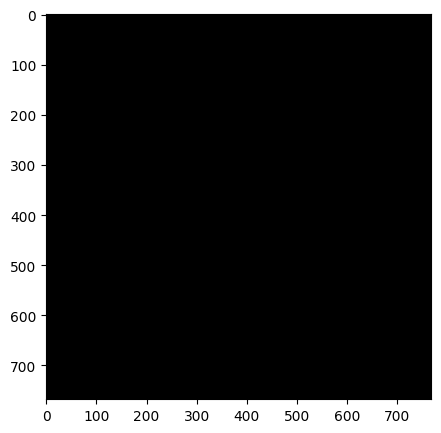

In [91]:
plt.figure(figsize=(5,5))
plt.imshow(masks_img, cmap='jet')
plt.show()

In [92]:
masks_img.shape

(768, 768, 3)

In [93]:
masks_img.dtype

dtype('uint8')

In [94]:
np.max(masks_img)

0

In [95]:
np.min(masks_img)

0

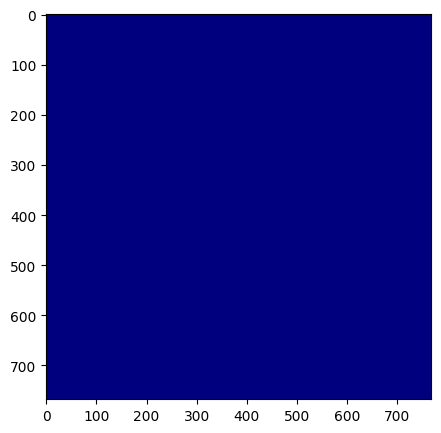

In [97]:
# masks_img[masks_img == 1] = 255

b, g, r    = masks_img[:, :, 0], masks_img[:, :, 1], masks_img[:, :, 2] # For RGB image

plt.figure(figsize=(5,5))
plt.imshow(g, cmap='jet')
plt.show()